<a href="https://colab.research.google.com/github/ilariatomei2004-gif/esercitazioni/blob/main/Notebook_GNN_quasiok_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

repo_name = 'progetto_GraphColouring_ML26'
repo_url = 'https://github.com/gien-7/progetto_GraphColouring_ML26.git' #importa proprio da github

if not os.path.exists(repo_name):
    !git clone {repo_url}
else:
    print(f"La cartella '{repo_name}' è già caricata")

Cloning into 'progetto_GraphColouring_ML26'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 74 (delta 28), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 3.44 MiB | 7.49 MiB/s, done.
Resolving deltas: 100% (28/28), done.


In [ ]:
from torch.utils.data import TensorDataset, Dataset, DataLoader
import torch
import torch.utils.data as data

!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 81.4 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

#### Si definisce una funzione per settare tutti i seed a un valore (randomico o meno che sia), quindi il seed relativo a pytorch, normale, ecc...

In [ ]:
import random
import numpy as np
import torch

def universal_seed(seed = 42):
    """Imposta il seed per la riproducibilità su Python, NumPy, PyTorch e ambiente."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Determinismo per gli algoritmi pytorch:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Seed impostato su {seed}")

In [ ]:
seed = 42
universal_seed(seed)

Seed impostato su 42


#Preprocessing

In [ ]:
import pandas as pd

file1 = 'progetto_GraphColouring_ML26/g6.col'  # queen9x9
file2 = 'progetto_GraphColouring_ML26/g17.col'  # miles750

df_g6 = pd.read_csv(file1, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])
df_g17 = pd.read_csv(file2, sep='\s+', skiprows=4, usecols=[1,2], names=['node1','node2'])

print('Shape g6.col  : ',df_g6.shape)
print('Shape g17.col : ',df_g17.shape)

Shape g6.col  :  (2112, 2)
Shape g17.col :  (4226, 2)


##queen9x9

In [ ]:
print(df_g6) #ogni donna puo interagire con le caselle che ha intorno (al bordo ha meno caselle)
#node 1 ti da la casella di partenza, node 2 quelle a cui è collegata
#il filw contiene quindi tutti gli edges

      node1  node2
0         1     11
1         1     21
2         1     31
3         1     41
4         1     51
...     ...    ...
2107     81     21
2108     81     18
2109     81     11
2110     81      9
2111     81      1

[2112 rows x 2 columns]


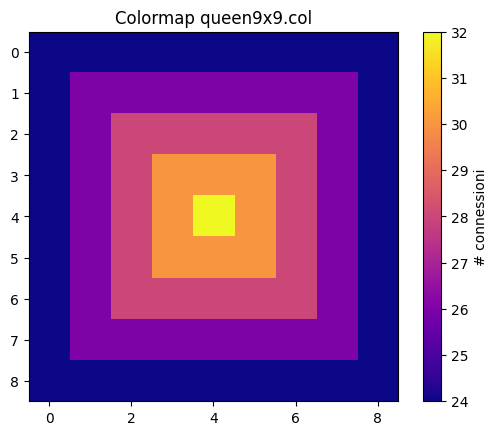

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
#meno sei al centro meno connesioni hai
unique, counts = np.unique(df_g6['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
# unique prende una volta sola gli elementi, values trasforma in array
queen_intensity = counts.reshape(9,9) #trasformo l'arary in griglia

plt.imshow(queen_intensity, cmap='plasma')
plt.colorbar(label = '# connessioni')
plt.title('Colormap queen9x9.col')
plt.show()

In [ ]:
index_grid = (unique-1).reshape(9,9) #indice di ogni nodo, scacchiera
index_grid

array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23, 24, 25, 26],
       [27, 28, 29, 30, 31, 32, 33, 34, 35],
       [36, 37, 38, 39, 40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49, 50, 51, 52, 53],
       [54, 55, 56, 57, 58, 59, 60, 61, 62],
       [63, 64, 65, 66, 67, 68, 69, 70, 71],
       [72, 73, 74, 75, 76, 77, 78, 79, 80]])

**Data augmentation sfruttando invarianze per simmetria del problema**

In [ ]:
from torch_geometric.utils import to_undirected

def build_edges_from_df(col1, col2):
  src = torch.tensor(col1.values, dtype=torch.long)  # nodo 1, formato long perchè va cosi
  dst = torch.tensor(col2.values, dtype=torch.long)
  edge_index = torch.stack([src, dst], dim=0)
  return to_undirected(edge_index)  # grafo non orientato

#data aigmentation qui non avrebbe molto senso ma può essere utile per evitare di memorizzare soluzioni sbagliata (DA VALUTARE)
def transform_node_index(x, y, k_rot, do_flip=False): #combinazione di rotazione e riflessione (8)
    if do_flip:
        x=-x
    for _ in range(k_rot):
        # Rotazione 90°: (x, y) -> (y, -x)
        x, y = y, -x
    pos_n_aug = torch.stack([x, y], dim=1) #gia in tensore
    return pos_n_aug

def transform_edges(serie, k_rot, do_flip=False): #cambia la mappa degli edges in funzione della rotazione dei nodi
  idx = serie-1  # da 1->81 a 0->80
  r = idx // 9
  c = idx % 9
  if do_flip:
    c = 8 - c
  for _ in range(k_rot):
    r, c = c, 8 - r
  return (r * 9 + c) +1 #da 0->80 a 1->81

In [ ]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

class QueenGraphGenerator(Dataset):
    def __init__(self, X, df, AUGMENT=True):
      super().__init__()
      self.X = X  # intenità nodi
      self.df = df
      self.AUGMENT = AUGMENT

    def __len__(self):  # Ritorna la dimensione del dataset
      return len(self.X)

    def __getitem__(self, idx): #ritorna l'elemento idx del dataset
      intensity = self.X[idx].copy()
      node_list = self.df[idx].copy() # copy() per evitare che augment modifichi i dati originali
      col1_label = (self.df[idx].columns)[0]
      col2_label = (self.df[idx].columns)[1]

      k_rot = 0
      do_flip = False

      rows, cols = np.indices((9, 9)) #ripete numeri in colonne e righe
      rows = rows.reshape(-1) # [0,0,0...1,1,1...n,n,n]
      cols = cols.reshape(-1) # [0,1,2...,0,1,2,...]
      values = intensity[rows, cols].astype(np.float32)  # sarà unidimensionale avendo flattenato, è strano ma vabe, deve essere float32

      # data.pos contiene le coordinate geometriche non normalizzate delle connessioni sul piano 9x9.
      pos = torch.tensor(np.stack([rows, cols], axis=1), dtype=torch.float) # su asse 1 è sulle colonne, 81x2, coordinate possibili
      pos_n = (pos/8.) * 2. - 1.  #normalizza da -1 a 1

      '''
      L'augmentation ha il fine di cambiare l'ordine degli indici
      quindi magari [0][2]=(2) -> [8][6]=(79)'. Segue che, oltre a ruotare
      il tensore delle posizioni, dovrò anche cambiare i vari edges:
      la nuova posizione (79)' eredita le connessioni di (2), e viceversa per (2)'.
      D'altro canto, la feature d'intensity non varia per simmetria del problema!
      Per formalismo è stato fatto lo stesso.
      '''

      if self.AUGMENT: # solo in training!!
        k_rot = np.random.randint(0, 4)
        do_flip = np.random.choice([True, False])
        x_coords = pos_n[:, 0].clone()
        y_coords = pos_n[:, 1].clone()
        pos_n = transform_node_index(x_coords, y_coords, k_rot, do_flip)

        node_list[col1_label] = transform_edges(node_list[col1_label].values, k_rot, do_flip)
        node_list[col2_label] = transform_edges(node_list[col2_label].values, k_rot, do_flip)

        # aggiungi rumore gaussiano (noise injetion) con std = 0.01 (smanettare su questo magari?)
        pos_n = pos_n + torch.randn_like(pos_n) * 0.01


      # Creo vettore x contenente
      value = torch.tensor(values/values.sum(), dtype=torch.float).view(-1, 1) #trasforma l'array delle intensità in 2d con la famosa dim dummy.
      x = torch.cat([value], dim=1)  # torch vuole dimensione dummy delle label di x, ritorna coppie

      # L'output di build_knn_edges del tipo torch.Tensor(2, (num_nodes x k_eff)), interi int64
      edge_index = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
      # In input le due serie relative al dataframe, scalate di 1 (anzichè fare da 1->9 fa 0->8)

      # Problema unsupervised, uso y dummy pari a indici delle caselle
      #tensor_label = torch.arange(81, dtype=torch.long) #non è niente perche y prende i valori veri che in questo caso non ci sono. (possibile errore)

      return Data(x=x, edge_index=edge_index, y=None, pos=pos_n) #x è coordinata con intensità

In [ ]:
#se sei confuso con le shape prova qui, non runna...
'''rows = rows.reshape(-1)
cols = cols.reshape(-1)
print(np.stack([rows, cols], axis=0)) #dim 0 numero di array
print(np.stack([rows, cols], axis=1)) #dim 1 righe degli array, dim 2 colonne'''

'rows = rows.reshape(-1)\ncols = cols.reshape(-1)\nprint(np.stack([rows, cols], axis=0)) #dim 0 numero di array\nprint(np.stack([rows, cols], axis=1)) #dim 1 righe degli array, dim 2 colonne'

In [ ]:
queen_df = df_g6.copy()
N = 32 # randomizzerò 32 volte per epoca, sullo stesso grafo di partenza
multi_X = [queen_intensity] * N
multi_df = [queen_df] * N

queen_dataset = QueenGraphGenerator(multi_X, multi_df, AUGMENT=False) #chiedi per sicurezza
queen_loader = DataLoader(queen_dataset, batch_size=int(N/4), shuffle=True, num_workers=2, pin_memory=True, drop_last=True) #eventualmente batch_size=2

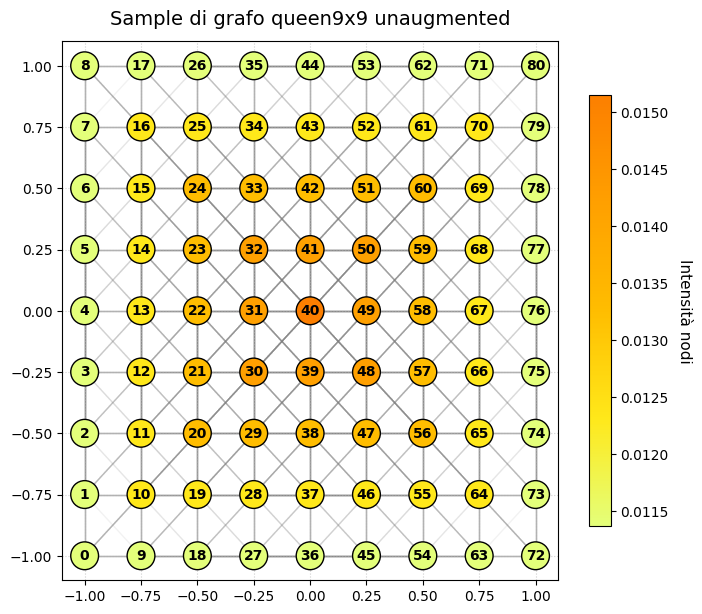

In [ ]:
from torch_geometric.utils import to_networkx
import networkx as nx

data = queen_dataset[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(data.num_nodes)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(G, pos_dict,
                               ax=ax,
                               node_size=400,
                               node_color=data.x[:, 0].numpy(),
                               cmap='Wistia',
                               edgecolors='black')

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.1, edge_color='gray')
nx.draw_networkx_labels(G, pos_dict, ax=ax,
                        font_size=10,
                        font_family='sans-serif',
                        font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

ax.set_axis_on()
ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)

x_coords = data.pos[:, 0].numpy()
y_coords = data.pos[:, 1].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.set_ylim(y_coords.min() - 0.1, y_coords.max() + 0.1)

ax.grid(True, linestyle=':', alpha=0.6)
ax.set_title("Sample di grafo queen9x9 unaugmented", fontsize=14, pad=12)

plt.show()

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print('Using',device, 'device')

Using cuda device


# Modello GNN
 Per evitare eccessiva simmetria e uguaglianza nelle features dei nodi usiamo **embedding learnable**. Alle features geometriche (x, y, intensità) aggiungiamo embedding casuale di dim 32 ad ogni nodo. La differenza con il classico embedding delle GNN è che viene aggiornato in ogni epoca pesandolo in base alla loss (emb = self.node_emb(node_ids) nel forward). Quindi all'inizio di ogni epoca ho le stesse features geometriche ma il resto dell'embedding è ottimizzato, come lo sono i pesi dei layer della GNN.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GNN_net(nn.Module):
    def __init__(self, c, N, i_dim=3):
        super().__init__()

        self.N = N
        self.node_emb = nn.Embedding(N, 32) # **

        self.conv1 = SAGEConv(i_dim + 32, 64)
        self.conv2 = SAGEConv(64, 64)

        self.fc = nn.Linear(64, c)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index

        node_ids = torch.arange(
            data.num_nodes,
            device=x.device
        ) % self.N #crea un array con 81 x batch_size e lo divide in una sequenza 0....80, 0....80,....

        emb = self.node_emb(node_ids) #emb.shape = [batch_size x 81, 32], qui sto pesando

        x_combined = torch.cat([x, emb], dim=-1) #unisco embedding learnable e features geometriche

        x_out = F.relu(self.conv1(x_combined, edge_index))
        x_out = F.relu(self.conv2(x_out, edge_index))

        logits = self.fc(x_out)

        return F.softmax(logits, dim=-1)


In [ ]:
model = GNN_net(c=12, N=81).to(device) #abbiamo esperienza di casi con 12 colori e 0 conflitti
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

GNN_net(
  (node_emb): Embedding(81, 32)
  (conv1): SAGEConv(35, 64, aggr=mean)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (fc): Linear(in_features=64, out_features=12, bias=True)
)
Numero di parametri trainabili: 16172


In [ ]:
def potts_loss(p, edge_index):
    row, col = edge_index
    mask = row < col # evita doppio conteggio
    row, col = row[mask], col[mask]

    return (p[row] * p[col]).sum(dim=1).mean()

def count_conflicts(colors, edge_index):
    row, col = edge_index
    mask = row < col
    row, col = row[mask], col[mask]
    return (colors[row] == colors[col]).sum().item()

In [ ]:
# prova su un solo batch
batch = next(iter(queen_loader))
batch = batch.to(device) # sposta tutti i tensori della Batch PyG sulla device

prob = model(batch)

print('output shape: ', prob.shape)
print('num grafi nella batch: ', batch.num_graphs)
print('num nodi nella batch: ', batch.num_nodes)

# loss
loss = potts_loss(prob, batch.edge_index)

print('loss: ', loss.item()) #.item() per prendere il numero, sarebbe un tensore

colors = prob.argmax(dim=1)
conflicts = count_conflicts(colors, batch.edge_index)
print('numero di conflitti: ', conflicts) #da dividere per batch_size

RuntimeError: mat1 and mat2 shapes cannot be multiplied (81x33 and 35x64)

Dobbiamo capire cosa fare con augmentation. Non sembra migliorare le cose e ovviamente vanno diminuite le epoche altrimenti ci mette più di 30 min. Prima di runnare modifica la cella delle batches (ad esempio metti N=1 e batch_size=1). Ovviamente il numero di conflitti va diviso per il numero di grafi nelle batches.

In [ ]:
#training loop

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

model.train()

for epoch in range(2000):

  for batch_idx, batch in enumerate(queen_loader): #batch_idx per ora non serve ma non si sa mai

    batch = batch.to(device)
    optimizer.zero_grad() #sennò somma i pesi

    p = model(batch)


    potts = potts_loss(p, batch.edge_index)

    entropy = -(p * torch.log(p + 1e-9)).sum(dim=1).mean()


    #l'entropia forza la rete ad esplorare.
    loss = potts - 0.01 * entropy

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        colors = p.argmax(dim=1)
        conflicts = count_conflicts(colors, batch.edge_index)
        max_prob = p.max(dim=1).values.mean().item() #massima probabilità di p

        print(epoch, f"Loss Tot: {loss.item():.4f}", f"Potts: {potts.item():.4f}", f"Conf: {conflicts}", f"MaxProb: {max_prob:.4f}")



0 Loss Tot: 0.0598 Potts: 0.0846 Conf: 4128 MaxProb: 0.1037
0 Loss Tot: 0.0597 Potts: 0.0845 Conf: 3912 MaxProb: 0.1029
0 Loss Tot: 0.0596 Potts: 0.0844 Conf: 3728 MaxProb: 0.1021
0 Loss Tot: 0.0595 Potts: 0.0843 Conf: 3536 MaxProb: 0.1013
50 Loss Tot: 0.0585 Potts: 0.0833 Conf: 712 MaxProb: 0.0929
50 Loss Tot: 0.0585 Potts: 0.0833 Conf: 712 MaxProb: 0.0929
50 Loss Tot: 0.0585 Potts: 0.0833 Conf: 712 MaxProb: 0.0930
50 Loss Tot: 0.0585 Potts: 0.0833 Conf: 712 MaxProb: 0.0930
100 Loss Tot: 0.0490 Potts: 0.0680 Conf: 560 MaxProb: 0.3158
100 Loss Tot: 0.0489 Potts: 0.0678 Conf: 568 MaxProb: 0.3175
100 Loss Tot: 0.0488 Potts: 0.0677 Conf: 568 MaxProb: 0.3191
100 Loss Tot: 0.0487 Potts: 0.0675 Conf: 584 MaxProb: 0.3208
150 Loss Tot: 0.0276 Potts: 0.0362 Conf: 200 MaxProb: 0.6810
150 Loss Tot: 0.0275 Potts: 0.0360 Conf: 200 MaxProb: 0.6830
150 Loss Tot: 0.0274 Potts: 0.0358 Conf: 200 MaxProb: 0.6849
150 Loss Tot: 0.0272 Potts: 0.0356 Conf: 176 MaxProb: 0.6869
200 Loss Tot: 0.0054 Potts: 0.00

KeyboardInterrupt: 

##miles750

In [ ]:
print(df_g17) #connessione vuol dire vicine entro 750 miglia

      node1  node2
0         1    128
1         1    122
2         1    120
3         1    119
4         1    117
...     ...    ...
4221    128     14
4222    128      8
4223    128      7
4224    128      2
4225    128      1

[4226 rows x 2 columns]


In [ ]:
unique, counts = np.unique(df_g17['node1'].values, return_counts=True)  # non cambierebbe nulla se operassi invece su node2 per simmetria
miles_intensity = counts.astype(np.float32)

In [ ]:
G = nx.Graph()
G.add_edges_from(zip(df_g17['node1'], df_g17['node2']))

pos = nx.spring_layout(G, seed=seed) #stampa mantenendo le distanze con posizioni casuali

In [ ]:
import collections

od = collections.OrderedDict(sorted(pos.items()))  #ordina dizionario dalle keys
od_keys = []
od_vals = []
for k, v in od.items():
  od_keys.append(k)
  od_vals.append(v)

od_vals = np.array(od_vals) #dizionario con posizioni farlocche di tutti i nodi (x,y)
#print(od_vals)
#od_keys è in struttura uguale a unique

In [ ]:
class MilesGraphGenerator(Dataset):
    def __init__(self, X, df, coords, AUGMENT=False):
        self.X = X
        self.df = df
        self.coords = coords
        self.AUGMENT = AUGMENT

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        intensity = self.X.copy()
        node_list = self.df.copy()
        coords_sim = self.coords.copy()
        col1_label = (self.df.columns)[0]
        col2_label = (self.df.columns)[1]

        edge_index_raw = build_edges_from_df(node_list[col1_label]-1, node_list[col2_label]-1)
        num_nodes = len(intensity)

        '''
        Augmentation con stessa filosofia di queen9x9, ma adesso non voglio ruotare
        secondo il gruppo di simmetria: essendo i nodi liberi, ovvero non dipendenti
        dalle posizioni ma dalle connessioni, mi concentro sul generalizzare il grafo
        permutando, con l'obiettivo di non incorrere in minimi come prima.
        '''

        if self.AUGMENT:
            perm = torch.randperm(num_nodes)  # rimescolamento degli indici
            intensity = intensity[perm]
            coords_sim = coords_sim[perm]
            #Rimappo gli archi affinché puntino ai nuovi indici
            reverse_perm = torch.empty_like(perm)
            reverse_perm[perm] = torch.arange(num_nodes)
            edge_index = reverse_perm[edge_index_raw]
        else:
            edge_index = edge_index_raw

        pos = torch.tensor(coords_sim, dtype=torch.float)
        p_min, p_max = pos.min(), pos.max()
        pos_n = ((pos - p_min) / (p_max - p_min + 1e-7)) * 2. - 1.

        val_t = torch.tensor(intensity / (intensity.sum() + 1e-7), dtype=torch.float).view(-1, 1)

        x = torch.cat([val_t, pos_n], dim=1)

        return Data(x=x, edge_index=edge_index, y=None, pos=pos_n)

In [ ]:
# N e batches da definire nell'allenamento
miles_df = df_g17.copy()
N = 1 # randomizzerò 800 volte per epoca, sullo stesso grafo di partenza
multi_X = [miles_intensity] * N
multi_df = [miles_df] * N
multi_od_vals = [od_vals] * N

miles_dataset = MilesGraphGenerator(miles_intensity, miles_df, od_vals, AUGMENT=False)
miles_loader = DataLoader(miles_dataset, batch_size=int(N), shuffle=True)

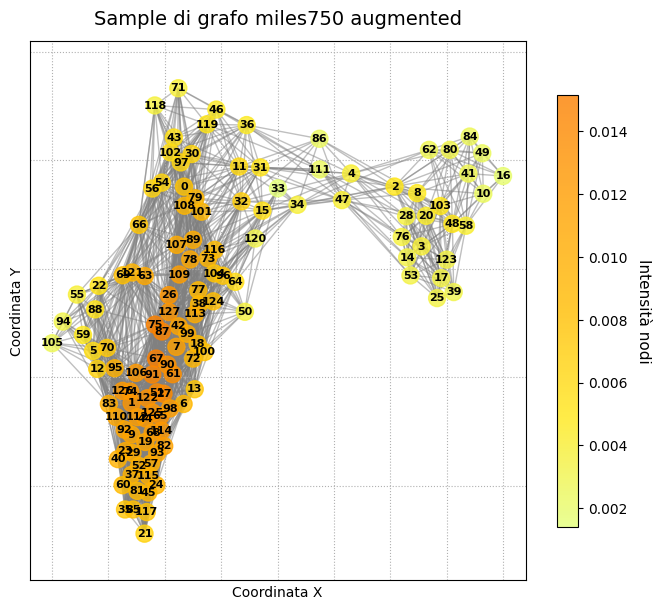

In [ ]:
data = miles_dataset[0]
G = to_networkx(data, to_undirected=True)
pos_dict = {i: data.pos[i].numpy() for i in range(128)}

fig, ax = plt.subplots(figsize=(8, 7))

nodes = nx.draw_networkx_nodes(
    G, pos_dict,
    ax=ax,
    node_size=150,
    node_color=data.x[:, 0].numpy(),
    cmap='Wistia',
    alpha=0.8
)

nx.draw_networkx_edges(G, pos_dict, ax=ax, alpha=0.5, edge_color="gray")
nx.draw_networkx_labels(G, pos_dict, ax=ax, font_size=8, font_weight='bold')

cbar = fig.colorbar(nodes, shrink = 0.8, ax=ax)
cbar.set_label('Intensità nodi', rotation=270, labelpad=17, fontsize=11)

x_coords = data.pos[:, 0].numpy()
ax.set_xlim(x_coords.min() - 0.1, x_coords.max() + 0.1)
ax.grid(True, linestyle=':', alpha=1.0)

ax.set_title("Sample di grafo miles750 augmented", fontsize=14, pad=12)
ax.set_xlabel("Coordinata X", fontsize=10)
ax.set_ylabel("Coordinata Y", fontsize=10)

plt.show()

In [ ]:
c = 31

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

class GNN_Miles750_Net(nn.Module):
    def __init__(self, num_colors=c, num_nodes=128, i_dim=3):
        """
        Modello GNN ottimizzato per la colorazione del grafo Miles750 Augmented.

        Args:
            num_colors (int): Numero di canali di output (c), idealmente >= 31.
            num_nodes (int): Numero totale di nodi univoci nel grafo (N).
            i_dim (int): Feature geometriche in ingresso (es. Coordinata X, Coordinata Y, Intensità).
        """
        super().__init__()

        self.N = num_nodes

        # Embedding strutturale per identificare univocamente i nodi nelle cricche dense.
        # Per 128 nodi, un embedding da 32 o 64 dimensioni è ideale.
        self.node_emb = nn.Embedding(num_nodes, 64)

        # Aumentiamo leggermente la capacità dei canali nascosti (da 64 a 128)
        # dato che miles750 ha densità e interconnessioni molto elevate nella zona centrale.
        self.conv1 = SAGEConv(i_dim+64, 128)
        self.conv2 = SAGEConv(128, 128)
        self.conv3 = SAGEConv(128, 128)
        self.conv4 = SAGEConv(128, 128)

        # Uno strato lineare finale per mappare le feature nei "c" colori disponibili
        self.fc = nn.Linear(128 + 64, num_colors)



    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Genera gli ID dei nodi tenendo conto di eventuali minibatch.
        # Nota: assicurati che data.num_nodes rifletta il numero effettivo di nodi nel batch.
        node_ids = torch.arange(
            data.num_nodes,
            device=x.device) % self.N


        # Recupera l'embedding posizionale
        emb = self.node_emb(node_ids)

        # Concatenazione delle feature geometriche (X, Y, intensità) con l'embedding
        h = torch.cat([x, emb], dim=-1)

        # Passaggi di Message Passing con GraphSAGE

        h1 = F.relu(self.conv1(h, edge_index))
        h2 = F.relu(self.conv2(h1, edge_index)) +h1
        h3 = F.relu(self.conv3(h2, edge_index)) +h2
        h4 = F.relu(self.conv4(h3, edge_index))+h3

        out = torch.cat([h4,emb], dim= -1 )

        # Calcolo dei logits per la classificazione del colore
        logits = self.fc(out)

        # Se usi CrossEntropyLoss durante il training, ricordati che PyTorch
        # preferisce ricevere i LOGITS grezzi. Se invece ti serve la distribuzione
        # di probabilità esplicita, tieni il Softmax.
        return logits

In [ ]:
model = GNN_Miles750_Net().to(device) #abbiamo esperienza di casi con 12 colori e 0 conflitti
print(model)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Numero di parametri trainabili:", num_params)

In [ ]:
def potts_loss(p, edge_index):
    row, col = edge_index
    mask = row < col # evita doppio conteggio
    row, col = row[mask], col[mask]
    conflict_prob = (p[row] * p[col]).sum(dim=1)

    return conflict_prob.mean()

def entropy_loss(p):
  return -(p*torch.log(p+1e-9)).sum(dim=1).mean()

def count_conflicts(colors, edge_index):
    row, col = edge_index
    mask = row < col
    row, col = row[mask], col[mask]
    return (colors[row] == colors[col]).sum().item()

In [ ]:
batch = next(iter(miles_loader))
batch = batch.to(device) # sposta tutti i tensori della Batch PyG sulla device

logits= model (batch)
p = F.softmax(logits, dim =-1)

print('output shape: ', p.shape)
print('num grafi nella batch: ', batch.num_graphs)
print('num nodi nella batch: ', batch.num_nodes)

# loss
loss = potts_loss(p, data.edge_index)

print('loss: ', loss.item()) #.item() per prendere il numero, sarebbe un tensore

colors = p.argmax(dim=1)
conflicts = count_conflicts(colors, batch.edge_index)
print('numero di conflitti: ', conflicts) #da dividere per batch_size

In [ ]:
model=GNN_Miles750_Net(num_colors=c, num_nodes=batch.num_nodes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay = 1e-6)
num_epochs= 4000
best_conflicts = 10**9
best_logits= None
for epoch in range(num_epochs):
        optimizer.zero_grad()
        logits = model(batch)

        temp = max(0.04, 2.5 * (0.9995 ** epoch))
        p = F.softmax(logits/temp , dim=-1)


        potts = potts_loss(p,batch.edge_index)
        ent = entropy_loss(p)

        #entropy weitght cresce col tempo
        ent_w = min(0.025, epoch / 8000 * 0.025)

        loss = potts + ent_w * ent

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()


        if epoch % 100 == 0:
            colors = logits.argmax(dim=1)
            conflicts = count_conflicts(colors, batch.edge_index)
            if conflicts < best_conflicts:
                best_conflicts = conflicts
                best_logits = logits.detach().clone()
            print("step", epoch,'loss', loss.item(),'conflicts:', conflicts, "best", best_conflicts)

In [ ]:
def repair_with_escape(edge_index, num_nodes, num_colors, init_colors,
                       max_steps=300000, patience=3000):
    row, col = edge_index
    mask = row < col
    row, col = row[mask], col[mask]
    device = edge_index.device

    colors = init_colors.clone()
    best_colors = colors.clone()
    best_conf = 10**9
    stuck = 0

    def count():
        return (colors[row] == colors[col]).sum().item()

    for step in range(max_steps):
        conf_edges = colors[row] == colors[col]
        n_conf = conf_edges.sum().item()

        if n_conf < best_conf:
            best_conf = n_conf
            best_colors = colors.clone()
            stuck = 0
            print("step", step, "best", best_conf)

        if n_conf == 0:
            print("RISOLTO", step)
            return colors

        stuck += 1

        bad_nodes = torch.cat([row[conf_edges], col[conf_edges]]).unique()

        # se bloccato a 1, perturba anche vicini dei nodi conflittuali
        if stuck > patience:
            neighs = []
            for v in bad_nodes:
                neighs.append(col[row == v])
                neighs.append(row[col == v])
            neighs = torch.cat(neighs).unique()

            pool = torch.cat([bad_nodes, neighs]).unique()

            k = min(5, len(pool))
            chosen = pool[torch.randperm(len(pool), device=device)[:k]]
            colors[chosen] = torch.randint(num_colors, (k,), device=device)

            stuck = 0
            continue

        # mossa min-conflicts normale
        v = bad_nodes[torch.randint(len(bad_nodes), (1,), device=device)].item()

        neighbors = torch.cat([
            col[row == v],
            row[col == v]
        ])

        best_c = colors[v].item()
        best_local = 10**9

        for c in torch.randperm(num_colors, device=device):
            c = c.item()
            local_conf = (colors[neighbors] == c).sum().item()

            if local_conf < best_local:
                best_local = local_conf
                best_c = c

        colors[v] = best_c

    print("Non risolto. Migliore:", best_conf)
    return best_colors

In [ ]:
colors = repair_with_escape(
    batch.edge_index,
    num_nodes=batch.num_nodes,
    num_colors=c,
    init_colors=best_logits.argmax(dim=1),
    max_steps=10000,
    patience=2000
)

print(count_conflicts(colors, batch.edge_index))